In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

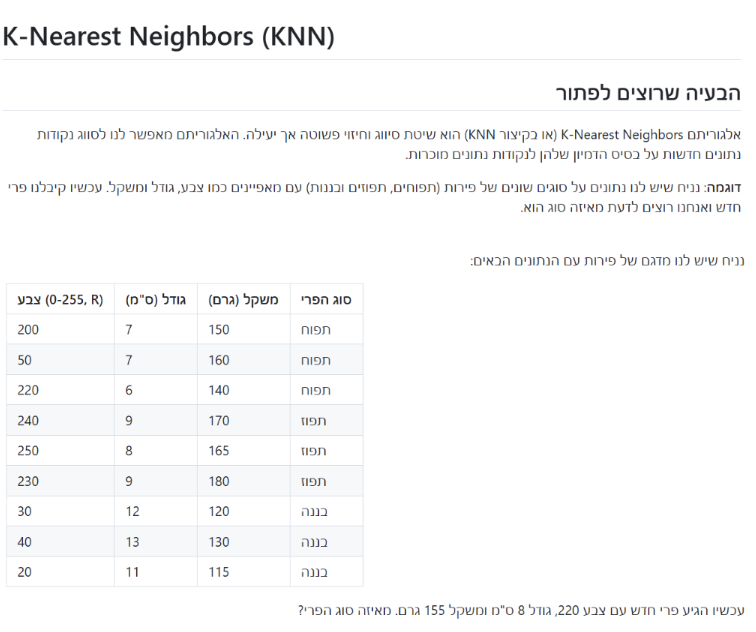

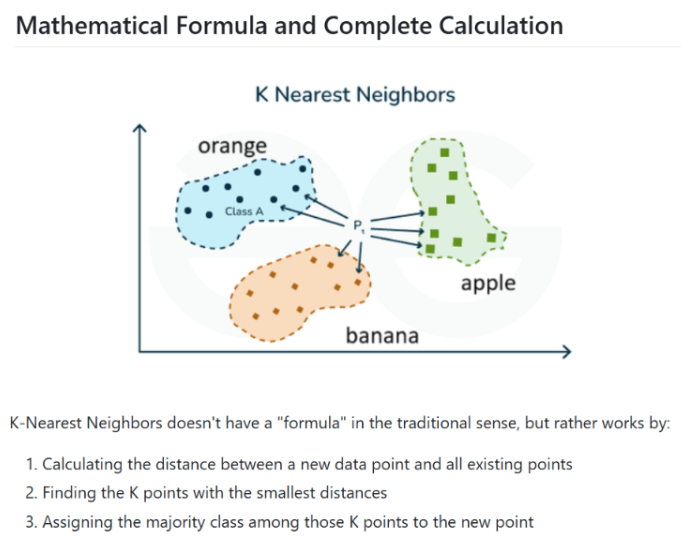

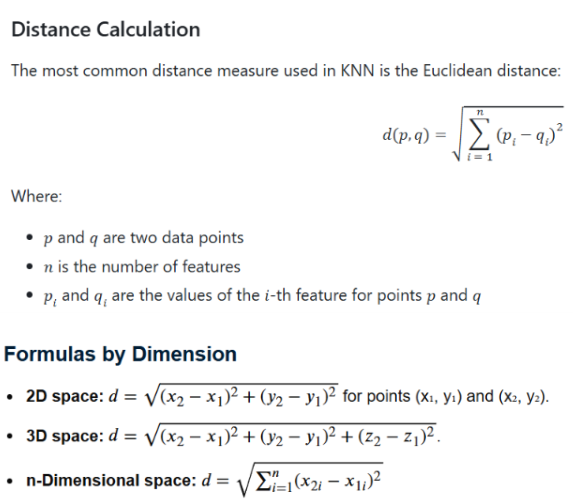

In [2]:
# x = p 4, 8, 9
# x = q 6
#       2  2  3

#     
# p = (1, 4) (2, 7) (3, 3)
# q   (4, 5)
#     (1, 4)
#     [(3)² + (1)²]
#     [9 + 1]
#     √10 = 3.162

#     (2, 7) = √8 = 2.82
#     (3, 3) = √5 = 2.23

In [3]:

# Xnorm = Xi - Xmin
#         ─────────
#         Xmax - Xmin

Xmax = 250
Xmin = 20
x = 200

# 200 ? --> 200 - 20      180
#           ────────  =   ─── = 0.78
#           250 - 20      230 

# 250 ? == 1
#  20 ? == 0

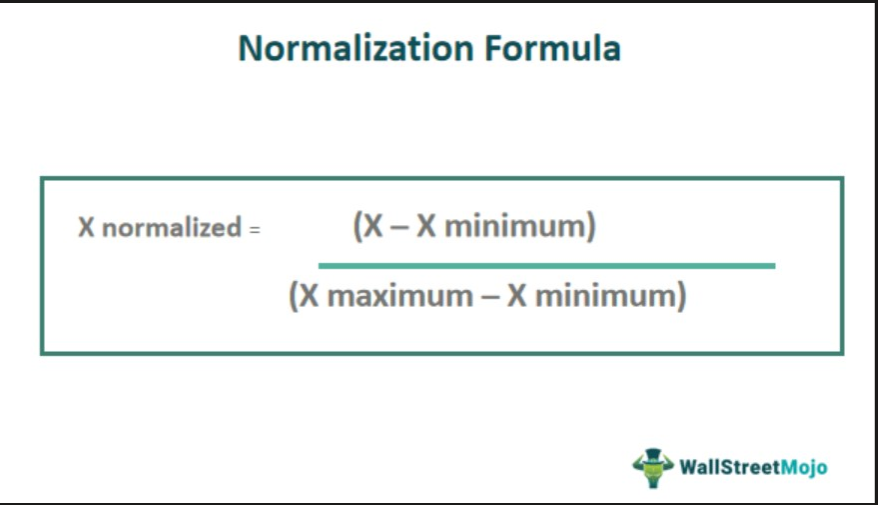

In [4]:
df = pd.DataFrame({
    "Fruit": ["Apple", "Apple", "Apple",
              "Orange", "Orange", "Orange",
              "Banana", "Banana", "Banana"],
    "Weight": [150, 160, 140, 170, 165, 180, 120, 130, 115],
    "Size": [7, 7, 6, 9, 8, 9, 12, 13, 11],
    "Color": [200, 50, 220, 240, 250, 230, 30, 40, 20]
})
display(df)

,Fruit,Weight,Size,Color
0,Apple,150,7,200
1,Apple,160,7,50
2,Apple,140,6,220
3,Orange,170,9,240
4,Orange,165,8,250
5,Orange,180,9,230
6,Banana,120,12,30
7,Banana,130,13,40
8,Banana,115,11,20


In [5]:
# Now for our new fruit with values: color=220, size=8, weight=155
# 1 normalize
# 2 calc distance from this point to allother points
# 3 put the distances in a list (or array, or dict or whatever) + sort by dist from small -> large + print the first 5 smallest distances

In [6]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()  # create a numebr between 0-1

df_norm = df.copy()

######################### STEP 1 - normalize df
# 1 - each column seperately
#df_norm['Weight'] = scaler.fit_transform(df['Weight'].values.reshape(-1, 1))
#df_norm['Size'] = scaler.fit_transform(df['Size'].values.reshape(-1, 1))
#df_norm['Color'] = scaler.fit_transform(df['Color'].values.reshape(-1, 1))

# 2 - all columns in once
# fit_transform - find min + max and scale
df_norm[['Weight', 'Color', 'Size']] = min_max_scaler.fit_transform(df_norm[['Weight', 'Color', 'Size']])

######################### STEP 2 - normalize the fruit with the same scaler
new_fruit = pd.DataFrame({'Weight': [155], 'Color': [220], 'Size': [8] })

# transfom - scale only
new_fruit_norm = min_max_scaler.transform(new_fruit[['Weight', 'Color', 'Size']])
print('new_fruit_norm', new_fruit_norm)

######################### STEP 3 - find dist between the new_fruit and ALL other fruits
distances = []
for i in range(len(df_norm)):
    diff_arr = df_norm.iloc[i][['Weight', 'Color', 'Size']] - new_fruit_norm[0]
    dist = np.linalg.norm(diff_arr)  # [1,2,3] = √ [(1)² + (2)² + (3)²] == normal
    distances.append( (i, dist, df_norm.iloc[i]['Fruit']) )

######################### STEP 4 - sort by distance + choose first 5
def sort_by(row):
    return 
sorted(distances, key=lambda item:item[1])[:5]

# d =[{'id': 1, 'dist': 3}, {'id':2, 'dist':2}]
# sorted(d, key=lambda item:item['dist'])

new_fruit_norm [[0.61538462 0.86956522 0.28571429]]


[(0, np.float64(0.18408356716879312), 'Apple'),
 (4, np.float64(0.20169747536206847), 'Orange'),
 (3, np.float64(0.2849983119390297), 'Orange'),
 (2, np.float64(0.3672697794960086), 'Apple'),
 (5, np.float64(0.4125863746131085), 'Orange')]

In [7]:
# Fruit data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

colors = np.array([200, 50, 220, 240, 250, 230, 30, 40, 20])
sizes = np.array([7, 7, 6, 9, 8, 9, 12, 13, 11])
weights = np.array([150, 160, 140, 170, 165, 180, 120, 130, 115])
fruit_types = np.array(['apple', 'apple', 'apple', 'orange', 'orange', 'orange', 'banana', 'banana', 'banana'])

# Create feature matrix
X = np.column_stack((colors, sizes, weights))
y = fruit_types

# Normalize data
scaler = MinMaxScaler()  # create 
X_scaled = scaler.fit_transform(X)  # activate

k = 3  # number of neighbors
# weights = uniform --  All points in each neighborhood are weighted equally
# weights = distance -- weight points by the inverse of their distance.
#                       closer neighbors of a query point will have a greater
#                       influence than neighbors which are further away.
model = KNeighborsClassifier(n_neighbors=k, weights='distance')  # prepare the engine: how many k? which method?

model.fit(X_scaled, y)  # store the points 

# New fruit to classify
new_fruit = np.array([[220, 8, 155]])
new_fruit_scaled = scaler.transform(new_fruit)

prediction = model.predict(new_fruit_scaled)
probabilities = model.predict_proba(new_fruit_scaled)
print(model.classes_)
print(probabilities)

# Output result
print(f"Prediction: The new fruit is a {prediction[0]}")

['apple' 'banana' 'orange']
[[0.39084138 0.         0.60915862]]
Prediction: The new fruit is a orange


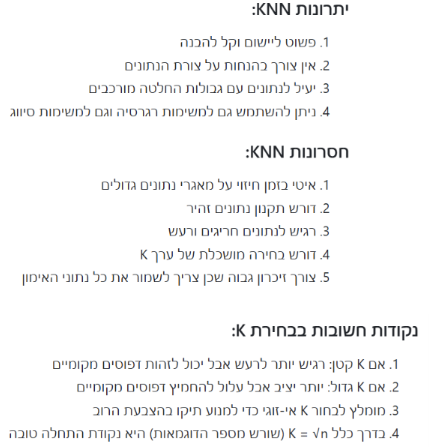